---
### **Task 1.0 — Project Workspace Verification**

Quick check on the local CentOS folders the pipeline will use.

In [1]:
import os

PROJECT_ROOT = os.path.expanduser("~/Downloads/arabic_ai_detection")
print("Workspace:", PROJECT_ROOT)

# Walk through the folder once and list its contents (max 2 levels).
for root, dirs, files in os.walk(PROJECT_ROOT):
    depth = root.replace(PROJECT_ROOT, "").count(os.sep)
    if depth > 2:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root) or root}/")
    for f in files[:10]:
        print(f"{indent}  {f}")

Workspace: /home/abdullah/Downloads/arabic_ai_detection


In [4]:

import pandas   as pd
import numpy    as np

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

---
## **Phase 1: Environment Setup & Data Acquisition**

> **Tasks:** 1.1 – 1.4

---
### Task 1.1 — Install Required Libraries

In [6]:
import subprocess, sys

# A single one-liner install — much shorter than looping per package.
PACKAGES = ["datasets", "huggingface_hub", "pyarabic", "regex",
            "nltk", "wordcloud", "seaborn", "pyarrow"]

subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                       *PACKAGES,
                       "--trusted-host", "pypi.org",
                       "--trusted-host", "files.pythonhosted.org"])
print("Packages ready.")

Packages ready.


---
### **Task 1.2 — Initialize SparkSession (Local Mode)**

In [7]:
from pyspark.sql import SparkSession

# Build all the project paths in one place.
DATA_RAW       = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR     = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR    = os.path.join(PROJECT_ROOT, "reports", "figures")
for d in (DATA_RAW, DATA_PROCESSED, MODELS_DIR, REPORTS_DIR):
    os.makedirs(d, exist_ok=True)

LOCAL_RAW_PATH = os.path.join(DATA_RAW, "abstracts_raw.parquet")

# A short, builder-style Spark setup. local[*] uses all cores.
spark = (
    SparkSession.builder
        .appName("ArabicAIDetect_F014_F035")
        .master("local[*]")
        .config("spark.driver.memory",          "4g")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.driver.extraJavaOptions", "-Dfile.encoding=UTF-8")
        .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print(f"Spark {spark.version} | cores: {spark.sparkContext.defaultParallelism}")
print(f"Workspace: {PROJECT_ROOT}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/19 23:41:47 WARN Utils: Your hostname, localhost.localdomain, resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s3)
26/05/19 23:41:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 23:41:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.0.2 | cores: 3
Workspace: /home/abdullah/Downloads/arabic_ai_detection


---
### Task 1.3 — Download Dataset & Save to Local Parquet

In [8]:
from datasets import load_dataset

# Optional authentication — if HF_TOKEN is exported.
if os.environ.get("HF_TOKEN"):
    from huggingface_hub import login
    login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)

# One call pulls the whole dataset.
dataset = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")
print("Splits:", list(dataset.keys()))

/home/abdullah/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Splits: ['by_polishing', 'from_title', 'from_title_and_content']


In [9]:
# Flatten the wide table directly into a list of dicts.
# Each iteration emits 1 human row + up to 4 AI rows per source record.

rows = []
for split_name, split_data in dataset.items():
    split_pdf = split_data.to_pandas()

    for _, row in split_pdf.iterrows():
        # Human (label = 1)
        rows.append({"abstract_text": row["original_abstract"],
                     "source_split":  split_name,
                     "generated_by":  "human",
                     "label":         1})

        # AI generations (label = 0)
        for model in ["allam", "jais", "llama", "openai"]:
            col = f"{model}_generated_abstract"
            if col in row and pd.notna(row[col]):
                rows.append({"abstract_text": row[col],
                             "source_split":  split_name,
                             "generated_by":  model,
                             "label":         0})

pdf = pd.DataFrame(rows)
print("Shape:", pdf.shape)
print(pdf["label"].value_counts())

Shape: (41940, 4)
label
0    33552
1     8388
Name: count, dtype: int64


In [10]:
# Persist once — Parquet is small, typed and Spark-native.
pdf.to_parquet(LOCAL_RAW_PATH, index=False, engine="pyarrow")
print(f"Saved → {LOCAL_RAW_PATH} ({os.path.getsize(LOCAL_RAW_PATH)/1024/1024:.2f} MB)")

Saved → /home/abdullah/Downloads/arabic_ai_detection/data/raw/abstracts_raw.parquet (18.63 MB)


---
### Task 1.4 — Initial Data Exploration with Spark DataFrames

In [11]:
from pyspark.sql import functions as F

# Read & cache (we'll use this DataFrame many times below).
raw_df = spark.read.parquet(LOCAL_RAW_PATH).cache()

print("Schema:")
raw_df.printSchema()

print(f"\nTotal rows: {raw_df.count():,}\n")
raw_df.show(5, truncate=80)

Schema:
root
 |-- abstract_text: string (nullable = true)
 |-- source_split: string (nullable = true)
 |-- generated_by: string (nullable = true)
 |-- label: long (nullable = true)




Total rows: 41,940

+--------------------------------------------------------------------------------+------------+------------+-----+
|                                                                   abstract_text|source_split|generated_by|label|
+--------------------------------------------------------------------------------+------------+------------+-----+
|كثيرا ما ارتبطت المصادر التاريخية في الأندلس خاصة منها كتب التراجم والفهرسات ...|by_polishing|       human|    1|
|يتناول هذا البحث موضوع التعليم بين النساء الأندلسيات من خلال دراسة المصادر ال...|by_polishing|       allam|    0|
|تدرس هذه الدراسة دور المرأة في التعليم في الأندلس من خلال مصادر تاريخية مثل ك...|by_polishing|        jais|    0|
|يُقدم هذا البحث دراسة شاملة حول حالة التعليم عند المرأة الأندلسية خلال العصور...|by_polishing|       llama|    0|
|صور نظام التعليم عند المرأة الأندلسية تستند إلى دراسة دقيقة للمصادر التاريخية...|by_polishing|      openai|    0|
+----------------------------------------------------------

In [12]:
# Class & source distributions in two short queries.

print("--- Label x Generator ---")
raw_df.groupBy("label", "generated_by").count().orderBy("label").show()

print("--- Source Split ---")
raw_df.groupBy("source_split").count().show()

--- Label x Generator ---
+-----+------------+-----+
|label|generated_by|count|
+-----+------------+-----+
|    0|      openai| 8388|
|    0|        jais| 8388|
|    0|       allam| 8388|
|    0|       llama| 8388|
|    1|       human| 8388|
+-----+------------+-----+

--- Source Split ---
+--------------------+-----+
|        source_split|count|
+--------------------+-----+
|        by_polishing|14255|
|from_title_and_co...|12870|
|          from_title|14815|
+--------------------+-----+



In [13]:
# A single chained query: char/word stats per label.

stats = (
    raw_df
        .withColumn("char_count", F.length("abstract_text"))
        .withColumn("word_count", F.size(F.split("abstract_text", r"\s+")))
        .groupBy("label")
        .agg(F.round(F.mean("char_count"), 2).alias("avg_chars"),
             F.min("char_count").alias("min_chars"),
             F.max("char_count").alias("max_chars"),
             F.round(F.mean("word_count"), 2).alias("avg_words"))
)
stats.show()

[Stage 13:======================================>                   (2 + 1) / 3]

+-----+---------+---------+---------+---------+
|label|avg_chars|min_chars|max_chars|avg_words|
+-----+---------+---------+---------+---------+
|    1|   740.31|      411|     1891|   119.16|
|    0|    654.6|      170|    18459|   101.49|
+-----+---------+---------+---------+---------+



#### Type-Token Ratio warm-up

A quick RDD computation just to feel out how easy stylometry is in Spark.

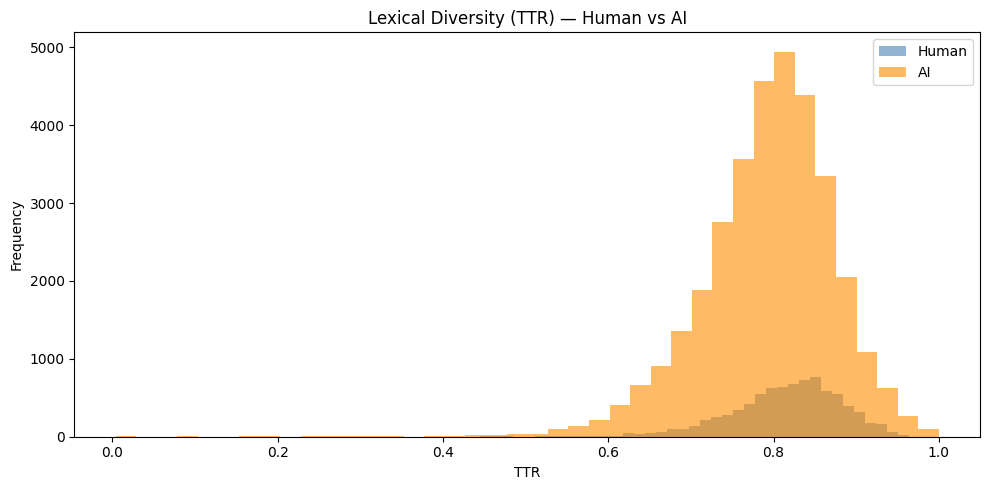

In [14]:
# Compute TTR per row as one mapping step on the RDD.
ttr_pdf = (
    raw_df.select("abstract_text", "label").rdd
          .map(lambda r: (
              int(r["label"]),
              (len(set(r["abstract_text"].split())) / len(r["abstract_text"].split()))
              if r["abstract_text"] and r["abstract_text"].split() else 0.0
          ))
          .toDF(["label", "ttr"]).toPandas()
)

# Plot inline — no separate helper, just matplotlib.
plt.figure(figsize=(10, 5))
plt.hist(ttr_pdf.loc[ttr_pdf.label==1, "ttr"], bins=40, alpha=0.6,
         color="steelblue", label="Human")
plt.hist(ttr_pdf.loc[ttr_pdf.label==0, "ttr"], bins=40, alpha=0.6,
         color="darkorange", label="AI")
plt.title("Lexical Diversity (TTR) — Human vs AI")
plt.xlabel("TTR"); plt.ylabel("Frequency"); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "ttr_eda_distribution.png"), dpi=150)
plt.show()

---
## **Phase 2: Distributed Data Preprocessing & Storage**

> **Tasks:** 2.1 – 2.3

---
### Task 2.1 — Arabic Text Preprocessing Pipeline (Spark UDFs)

A single UDF that runs the four cleaning steps inline:
1. Strip diacritics.
2. Unify ا/إ/أ/آ, ى → ي, ة → ه; keep Arabic + space only.
3. Drop Arabic stop-words.
4. ISRI light-stem each surviving token.

In [15]:
import re
import nltk
nltk.download("stopwords", quiet=True)

from nltk.corpus     import stopwords
from nltk.stem.isri  import ISRIStemmer
from pyspark.sql.functions import udf
from pyspark.sql.types     import StringType

# Pre-build the stop-word set and the stemmer once at module load.
AR_STOPWORDS = set(stopwords.words("arabic"))
_STEMMER     = ISRIStemmer()

@udf(StringType())
def clean_arabic(text):
    """Full Arabic clean-up in one UDF (inline for clarity)."""
    if not isinstance(text, str):
        return ""

    # 1. diacritics
    text = re.sub(r"[\u0617-\u061A\u064B-\u065F]", "", text)

    # 2. character unification + keep only Arabic letters + space
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى",     "ي", text)
    text = re.sub(r"ة",     "ه", text)
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # 3 + 4. drop stop-words & stem each remaining token
    return " ".join(_STEMMER.stem(w) for w in text.split() if w not in AR_STOPWORDS)


# Apply: drop empties + duplicates, then add the cleaned column.
preprocessed_df = (
    raw_df
        .filter(F.col("abstract_text").isNotNull()
                & (F.trim(F.col("abstract_text")) != ""))
        .dropDuplicates(["abstract_text"])
        .withColumn("abstract_text_clean", clean_arabic("abstract_text"))
)

print(f"After preprocessing: {preprocessed_df.count():,} rows")
preprocessed_df.select("abstract_text", "abstract_text_clean").show(3, truncate=80)

After preprocessing: 36,525 rows


[Stage 27:>                                                         (0 + 1) / 1]

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                   abstract_text|                                                             abstract_text_clean|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|يُقدم هذا البحث دراسة شاملة حول حالة التعليم عند المرأة الأندلسية خلال العصور...|قدم بحث درس شمل حول حله علم راه دلس خلل عصر وسط كشف بحث خلل لسل ؤلف ارخ اندلس...|
|صور نظام التعليم عند المرأة الأندلسية تستند إلى دراسة دقيقة للمصادر التاريخية...|صور نظم علم راه دلس سند الي درس دقق صدر ارخ وثق حيه علماء ثقف دلس، سيم كتب رج...|
|انهيار دولة الموحدين يعود بشكل كبير للعوامل الثقافية، التي لا تقل أهمية عن ال...|هير دول وحد يعد شكل كبر عمل ثقافيه، تقل اهم عمل سيس عسكر بدئ فكر عقد ابن رت، ...|
+---------------

---
### Task 2.2 — Store Processed Data in Local Parquet

In [16]:
LOCAL_PROC_PATH = os.path.join(DATA_PROCESSED, "abstracts_preprocessed.parquet")

# Partition by label so per-class queries can skip files they don't need.
(
    preprocessed_df
        .repartition(8, "label")
        .write.mode("overwrite").partitionBy("label")
        .parquet(LOCAL_PROC_PATH)
)

print("Saved partitions:", os.listdir(LOCAL_PROC_PATH))

# Verify by reading back.
proc_df = spark.read.parquet(LOCAL_PROC_PATH).cache()
print(f"Reloaded rows: {proc_df.count():,}")

Saved partitions: ['label=0', 'label=1', '_SUCCESS', '._SUCCESS.crc']
Reloaded rows: 36,525


---
### Task 2.3 — EDA on Distributed Data + MapReduce Corpus Statistics

In [17]:
# Bigrams in 6 lines using Spark MLlib's NGram.

from pyspark.ml.feature import NGram

bigrams_df = (
    NGram(n=2, inputCol="tokens", outputCol="bigrams")
        .transform(proc_df.withColumn("tokens",
                                       F.split("abstract_text_clean", r"\s+")))
)

print("Top 20 bigrams:")
(bigrams_df.select(F.explode("bigrams").alias("bg"))
            .groupBy("bg").count().orderBy(F.desc("count"))
            .limit(20).show(truncate=False))

Top 20 bigrams:


+-------+-----+
|bg     |count|
+-------+-----+
|درس الي|14458|
|بحث الي|11819|
|ركز علي|11781|
|هدف درس|10444|
|ضوء علي|9544 |
|الي ان |7724 |
|هدف بحث|7214 |
|اثر علي|6064 |
|سلط ضوء|5447 |
|الي كشف|5397 |
|ضفه الي|4932 |
|ورق بحث|4895 |
|علي اهم|4724 |
|نول بحث|4563 |
|الي حلل|4405 |
|بحث علي|3910 |
|يمكن ان|3548 |
|توقع ان|3415 |
|الي درس|3394 |
|ظهر نتج|3304 |
+-------+-----+



#### Manual MapReduce (RDD)

The classic *word → (word, 1) → sum* pattern, built directly on RDDs.

In [18]:
# Three lines: flatMap, map, reduceByKey.

text_rdd = proc_df.select("abstract_text_clean").rdd.map(lambda r: r[0] or "")

word_counts_rdd = (
    text_rdd
        .flatMap(lambda t: t.split())            # MAP
        .map(lambda w: (w, 1))                   # MAP
        .reduceByKey(lambda a, b: a + b)         # REDUCE
        .sortBy(lambda kv: kv[1], ascending=False)
)

print("Top 20 words (MapReduce):")
for w, c in word_counts_rdd.take(20):
    print(f"  {w}: {c}")

Top 20 words (MapReduce):
  علي: 89367
  الي: 70929
  درس: 66307
  بحث: 53427
  علم: 37540
  ان: 32978
  حلل: 31232
  هدف: 30251
  جمع: 29295
  عمل: 26274
  خلل: 24473
  اثر: 23123
  خدم: 21862
  جزر: 20865
  فهم: 20757
  حقق: 20515
  عزز: 20009
  شكل: 19478
  نتج: 19365
  فعل: 18211


In [19]:
# Hapax legomena = words seen exactly once.

hapax_count = word_counts_rdd.filter(lambda kv: kv[1] == 1).count()
vocab_size  = word_counts_rdd.count()
print(f"Vocabulary: {vocab_size:,}  |  Hapax legomena: {hapax_count:,} "
      f"({hapax_count/vocab_size*100:.1f}%)")

Vocabulary: 26,628  |  Hapax legomena: 10,400 (39.1%)


In [21]:
spark.catalog.clearCache()

---
## **Phase 3: Scalable Feature Engineering & Batch Modeling**

> **Tasks:** 3.1 – 3.5

In [22]:
from collections        import Counter
from pyspark.sql.types   import DoubleType, IntegerType

clean_text_columns = "abstract_text_clean"

# ---------- f014 — Hapax Dislegomena Ratio --------------------------------

feature_name_f014 = f"{clean_text_columns}_f014_hapax_dislegomena_ratio"

def _hapax_dislegomena_ratio(words):
    """V2 / N — share of tokens that appear exactly twice."""
    N = len(words)
    if N == 0:
        return 0.0
    counts = Counter(w.lower() for w in words)
    V2 = sum(1 for v in counts.values() if v == 2)
    return float(V2) / N

# Spark UDF — takes the already-tokenised array<string> column.
@udf(DoubleType())
def f014_udf(words):
    return _hapax_dislegomena_ratio(words or [])


# ---------- f035 — Total number of paragraphs (P) -------------------------

feature_name_f035 = "f035_Total_number_of_paragraphs_(P)"

def _count_paragraphs(text):
    """A paragraph break is any blank line ('\n\n')."""
    if not isinstance(text, str) or not text.strip():
        return 0
    # split on >= 1 blank line, drop empty trailing/leading fragments
    parts = [p for p in re.split(r"\n\s*\n", text) if p.strip()]
    return len(parts)

@udf(IntegerType())
def f035_udf(text):
    return _count_paragraphs(text)

print("UDFs ready:", feature_name_f014, "|", feature_name_f035)

UDFs ready: abstract_text_clean_f014_hapax_dislegomena_ratio | f035_Total_number_of_paragraphs_(P)


In [23]:
# Apply both features in one chained call.

feat_df = (
    proc_df
        .withColumn("words", F.split(clean_text_columns, r"\s+"))
        .withColumn(feature_name_f014, f014_udf("words"))
        .withColumn(feature_name_f035, f035_udf("abstract_text"))
        .cache()
)

print(f"Rows: {feat_df.count():,}")
feat_df.select("label", feature_name_f014, feature_name_f035).show(5)

[Stage 55:======================================>                   (2 + 1) / 3]

Rows: 36,525
+-----+------------------------------------------------+-----------------------------------+
|label|abstract_text_clean_f014_hapax_dislegomena_ratio|f035_Total_number_of_paragraphs_(P)|
+-----+------------------------------------------------+-----------------------------------+
|    0|                             0.12745098039215685|                                  1|
|    0|                              0.1111111111111111|                                  1|
|    0|                              0.0990990990990991|                                  1|
|    0|                             0.09090909090909091|                                  1|
|    0|                              0.0673076923076923|                                  1|
+-----+------------------------------------------------+-----------------------------------+
only showing top 5 rows


---
### Task 3.2 — Advanced Features: TF-IDF Embedding (Spark MLlib)

In [24]:
from pyspark.ml         import Pipeline as MLPipeline
from pyspark.ml.feature import Tokenizer, HashingTF, IDF

tfidf_pipe = MLPipeline(stages=[
    Tokenizer(inputCol=clean_text_columns, outputCol="words_tok"),
    HashingTF(inputCol="words_tok", outputCol="raw_tf", numFeatures=10_000),
    IDF(inputCol="raw_tf", outputCol="tfidf_features"),
])

tfidf_model = tfidf_pipe.fit(feat_df)
tfidf_df    = tfidf_model.transform(feat_df)
print("TF-IDF ready.")

[Stage 61:======================================>                   (2 + 1) / 3]

TF-IDF ready.


---
### Task 3.3 — Feature Assembly & Data Splitting

In [25]:
from pyspark.ml.feature import VectorAssembler

ACTIVE_STYLO_COLS = [feature_name_f014, feature_name_f035]

assembler = VectorAssembler(
    inputCols=ACTIVE_STYLO_COLS + ["tfidf_features"],
    outputCol="features",
    handleInvalid="skip",
)

assembled_df = assembler.transform(tfidf_df)

# 70 / 15 / 15 split
train_df, val_df, test_df = assembled_df.randomSplit([0.7, 0.15, 0.15], seed=42)
train_df.cache(); test_df.cache()

print(f"train={train_df.count():,} | val={val_df.count():,} | test={test_df.count():,}")

[Stage 69:======================================>                   (2 + 1) / 3]

train=25,684 | val=5,403 | test=5,438


---
### Task 3.4 — Model Training & Evaluation

Four classifiers, evaluated by the same compact helper.

In [26]:
from pyspark.ml.classification import (LogisticRegression,
                                       RandomForestClassifier,
                                       LinearSVC,
                                       GBTClassifier)
from pyspark.ml.evaluation     import (BinaryClassificationEvaluator,
                                       MulticlassClassificationEvaluator)

# A 5-line helper instead of a long function with docstring.
def evaluate(model, data, name):
    p   = model.transform(data)
    auc = BinaryClassificationEvaluator(labelCol="label",
            metricName="areaUnderROC").evaluate(p)
    acc = MulticlassClassificationEvaluator(labelCol="label",
            metricName="accuracy").evaluate(p)
    f1  = MulticlassClassificationEvaluator(labelCol="label",
            metricName="f1").evaluate(p)
    print(f"{name:<24s} AUC={auc:.4f}  Acc={acc:.4f}  F1={f1:.4f}")
    return dict(AUC=auc, Accuracy=acc, F1=f1)


lr_model  = LogisticRegression(featuresCol="features", labelCol="label",
                               maxIter=50, regParam=0.01).fit(train_df)
lr_res    = evaluate(lr_model, test_df, "Logistic Regression")

rf_model  = RandomForestClassifier(featuresCol="features", labelCol="label",
                                   numTrees=100, maxDepth=10,
                                   seed=42).fit(train_df)
rf_res    = evaluate(rf_model, test_df, "Random Forest")

svm_model = LinearSVC(featuresCol="features", labelCol="label",
                      maxIter=50).fit(train_df)
svm_res   = evaluate(svm_model, test_df, "Linear SVM")

gbt_model = GBTClassifier(featuresCol="features", labelCol="label",
                          maxIter=50, maxDepth=8,
                          seed=42).fit(train_df)
gbt_res   = evaluate(gbt_model, test_df, "Gradient Boosted Trees")

Logistic Regression      AUC=0.9672  Acc=0.9562  F1=0.9529


Random Forest            AUC=0.9591  Acc=0.9167  F1=0.8769


Linear SVM               AUC=0.9517  Acc=0.9386  F1=0.9416


Gradient Boosted Trees   AUC=0.9580  Acc=0.9472  F1=0.9407


---
### Task 3.5 — Model Persistence

In [27]:
# One line per model — sklearn-style API.
lr_model .save(os.path.join(MODELS_DIR, "logistic_regression"))
rf_model .save(os.path.join(MODELS_DIR, "random_forest"))
svm_model.save(os.path.join(MODELS_DIR, "linear_svm"))
gbt_model.save(os.path.join(MODELS_DIR, "gbt_model"))
tfidf_model.save(os.path.join(MODELS_DIR, "tfidf_pipeline"))
print("Models on disk:", os.listdir(MODELS_DIR))

Models on disk: ['logistic_regression', 'random_forest', 'linear_svm', 'gbt_model', 'tfidf_pipeline']


---
## **Phase 4: Stream Processing & Comprehensive Evaluation**

> **Tasks:** 4.1 – 4.4

---
### Task 4.1 — Stream Simulation via Local File Source

In [28]:
import json, time

STREAM_IN   = os.path.join(PROJECT_ROOT, "streaming", "inbox")
STREAM_OUT  = os.path.join(PROJECT_ROOT, "streaming", "output")
STREAM_CKPT = os.path.join(PROJECT_ROOT, "streaming", "checkpoints")
for p in (STREAM_IN, STREAM_OUT, STREAM_CKPT):
    os.makedirs(p, exist_ok=True)

# Take 50 samples and split into 5 batches of 10.
samples = test_df.select("label", "abstract_text", "abstract_text_clean") \
                 .limit(50).collect()

for batch_id in range(5):
    batch    = samples[batch_id*10 : (batch_id+1)*10]
    out_path = os.path.join(STREAM_IN, f"batch_{batch_id:03d}.json")

    with open(out_path, "w", encoding="utf-8") as fh:
        for row in batch:
            fh.write(json.dumps({
                "abstract_text":       row["abstract_text"],
                "abstract_text_clean": row["abstract_text_clean"],
                "label":               int(row["label"]),
            }, ensure_ascii=False) + "\n")
    print(f"Wrote batch {batch_id}")
    time.sleep(0.5)

Wrote batch 0
Wrote batch 1
Wrote batch 2
Wrote batch 3
Wrote batch 4


---
### Task 4.2 — Real-Time Deployment with Spark Structured Streaming

In [29]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

stream_schema = StructType([
    StructField("abstract_text",       StringType(),  True),
    StructField("abstract_text_clean", StringType(),  True),
    StructField("label",               IntegerType(), True),
])

# Build the streaming pipeline as one big chain — same features as batch.
raw_stream_df = (
    spark.readStream
         .schema(stream_schema)
         .option("maxFilesPerTrigger", 1)
         .json(STREAM_IN)
)

stream_predictions = (
    raw_stream_df
        .withColumn("words", F.split(clean_text_columns, r"\s+"))
        .withColumn(feature_name_f014, f014_udf("words"))
        .withColumn(feature_name_f035, f035_udf("abstract_text"))
        .transform(tfidf_model.transform)
        .transform(assembler.transform)
        .transform(rf_model.transform)
        .select("abstract_text", "label", "prediction", "probability")
)

stream_query = (
    stream_predictions.writeStream
        .outputMode("append").format("parquet")
        .option("checkpointLocation", STREAM_CKPT)
        .option("path",               STREAM_OUT)
        .trigger(processingTime="5 seconds")
        .start()
)

print(f"Streaming active: {stream_query.isActive}")
time.sleep(30)
stream_query.stop()
print("Streaming stopped.")

Streaming active: True
Streaming stopped.


In [30]:
# Read predictions back and compute live accuracy.

import glob
files = glob.glob(os.path.join(STREAM_OUT, "**", "*.parquet"), recursive=True)

if files:
    df_out = spark.read.parquet(STREAM_OUT)
    n      = df_out.count()
    correct = df_out.filter(F.col("label") == F.col("prediction").cast("int")).count()
    print(f"Predictions: {n}  |  Live accuracy: {correct/n*100:.2f}%")
    df_out.select("label", "prediction").show(5)
else:
    print("No stream output yet.")

Predictions: 50  |  Live accuracy: 100.00%
+-----+----------+
|label|prediction|
+-----+----------+
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
+-----+----------+
only showing top 5 rows


---
### Task 4.3 — Comprehensive Evaluation: Metrics, ROC, Confusion Matrices

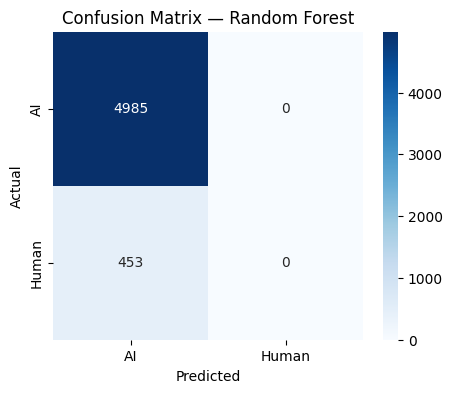

In [31]:
import seaborn as sns

# 1. Confusion matrix for the chosen model (RF).

preds  = rf_model.transform(test_df)
rows   = preds.groupBy("label", "prediction").count().collect()
cm     = np.zeros((2, 2), dtype=int)
for r in rows:
    cm[int(r["label"]), int(r["prediction"])] = int(r["count"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["AI", "Human"], yticklabels=["AI", "Human"])
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

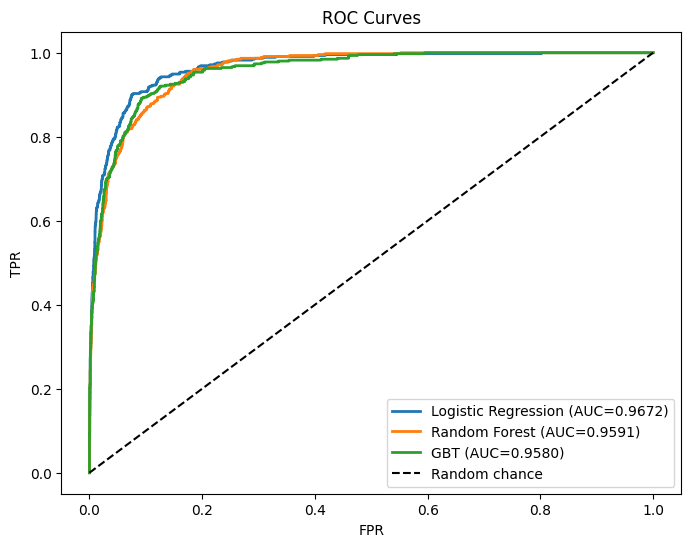

In [32]:
# 2. ROC curves (sklearn does the heavy lifting).

from sklearn.metrics import roc_curve, auc as sklearn_auc

plt.figure(figsize=(8, 6))
for name, model in [("Logistic Regression", lr_model),
                    ("Random Forest",       rf_model),
                    ("GBT",                  gbt_model)]:
    df_pred = (model.transform(test_df)
                    .select("label", "probability").rdd
                    .map(lambda r: (float(r["label"]), float(r["probability"][1])))
                    .toDF(["label", "score"]).toPandas())
    fpr, tpr, _ = roc_curve(df_pred["label"], df_pred["score"])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={sklearn_auc(fpr, tpr):.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random chance")
plt.title("ROC Curves"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(); plt.show()

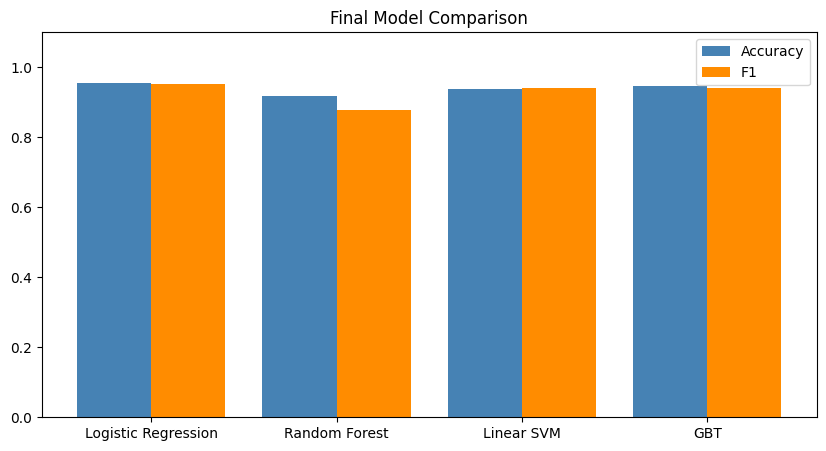

In [33]:
# 3. Bar-chart comparison (Accuracy & F1).

all_results = {"Logistic Regression": lr_res, "Random Forest": rf_res,
               "Linear SVM": svm_res, "GBT": gbt_res}
names = list(all_results.keys())
accs  = [all_results[m]["Accuracy"] for m in names]
f1s   = [all_results[m]["F1"]       for m in names]

x = np.arange(len(names))
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, accs, 0.4, label="Accuracy", color="steelblue")
plt.bar(x + 0.2, f1s,  0.4, label="F1",       color="darkorange")
plt.xticks(x, names); plt.ylim(0, 1.1)
plt.title("Final Model Comparison"); plt.legend(); plt.show()

---
### Task 4.4 — Scalability Benchmark: Throughput Analysis

Partitions= 4  →  2.06s


Partitions= 8  →  1.68s


Partitions=16  →  1.59s


[Stage 1191:=====================================>                  (2 + 1) / 3]

Partitions=32  →  1.66s


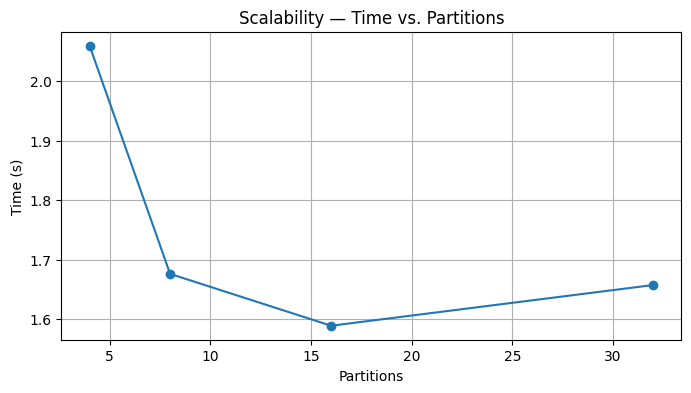

In [34]:
# Time the same count() under different parallelism levels.

times = []
for p in [4, 8, 16, 32]:
    spark.conf.set("spark.sql.shuffle.partitions", str(p))
    t0 = time.time()
    _  = assembled_df.repartition(p).count()
    times.append(time.time() - t0)
    print(f"Partitions={p:2d}  →  {times[-1]:.2f}s")

plt.figure(figsize=(8, 4))
plt.plot([4, 8, 16, 32], times, marker="o")
plt.title("Scalability — Time vs. Partitions")
plt.xlabel("Partitions"); plt.ylabel("Time (s)"); plt.grid(True)
plt.show()

---
## **Phase 5: Analysis, Interpretation & Final Reporting**

> **Tasks:** 5.1 – 5.3

---
### Task 5.1 — Model Comparison Summary

In [35]:
summary_df = pd.DataFrame([{
    "Model": name,
    "Accuracy": round(r["Accuracy"], 4),
    "F1": round(r["F1"], 4),
    "AUC": round(r["AUC"], 4),
} for name, r in all_results.items()]).sort_values("F1", ascending=False)

print(summary_df.to_string(index=False))

              Model  Accuracy     F1    AUC
Logistic Regression    0.9562 0.9529 0.9672
         Linear SVM    0.9386 0.9416 0.9517
                GBT    0.9472 0.9407 0.9580
      Random Forest    0.9167 0.8769 0.9591


---
### Task 5.2 — Feature Importance Analysis

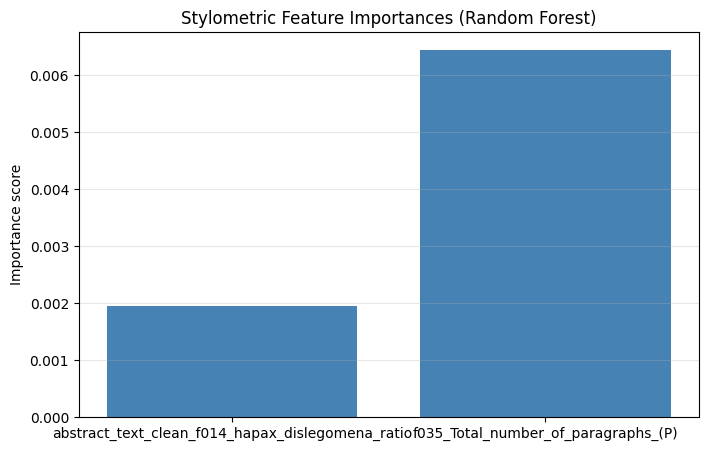

In [36]:
# Pull the two stylometric importances from the Random Forest model.

importances = rf_model.featureImportances.toArray()
stylo_imp   = importances[:len(ACTIVE_STYLO_COLS)]

plt.figure(figsize=(8, 5))
plt.bar(ACTIVE_STYLO_COLS, stylo_imp, color="steelblue")
plt.title("Stylometric Feature Importances (Random Forest)")
plt.ylabel("Importance score"); plt.grid(axis="y", alpha=0.3)
plt.savefig(os.path.join(REPORTS_DIR, "feature_importances.png"), dpi=150)
plt.show()

---
### Task 5.3 — Reproducibility Artefact

In [37]:
# Freeze the environment to a requirements.txt for grading.

req_path = os.path.join(PROJECT_ROOT, "requirements.txt")
with open(req_path, "w") as fh:
    fh.write(subprocess.run([sys.executable, "-m", "pip", "freeze"],
                            capture_output=True, text=True).stdout)
print(f"Requirements → {req_path}")

Requirements → /home/abdullah/Downloads/arabic_ai_detection/requirements.txt


In [38]:
spark.stop()
print("SparkSession terminated.")
print(f"Reports under: {REPORTS_DIR}")

SparkSession terminated.
Reports under: /home/abdullah/Downloads/arabic_ai_detection/reports/figures
